# Análise de Linguagem Natural

Este é um material de consulta sobre o quarto tópico de estudos. Sinta-se a vontade para voltar aqui sempre que necessário.

## Índice :
* [Expressões Regulares](#first-bullet)
* [Edição de Documentos](#second-bullet)


## Expressões Regulares <a class="anchor" id="first-bullet"></a>


A leitura de grandes volumes de textos jurídicos - decisões judiciais, contratos, legislação - com a finalidade de identificar normas e argumentos é uma parte essencial da ativdade de juristas em qualquer carreira. 

A busca por elementos jurídicos dentro de um texto é feita, por exemplo, localmente. Pense na tarefa de uma advogada que procura determinada cláusula dentro de um texto de contrato com 20 páginas. 
Essa busca também é feita em conjuntos maiores de arquivos. Uma equipe busca um determinado argumento sendo desenvolvido e fundamentado em alguma de 100 decisões judiciais. 
Alternativamente, a busca é feita utilizando ferramentas, que podem ter maior ou menos precisão, para identificar expressões como 'obrigação contratual' em conjuntos de milhares ou milhões de decisões judiciais. A maioria dos tribunais brasileiros disponibiliza a função de busca de suas decisões, porém com possibilidades muito limitadas de refinamento. 

Em um nível ainda maior de abrangência, ferramentas com o JusBrasil permitem a busca de uma expressão em decisões de dezenas de tribunais ao mesmo tempo. 
Segundo um dos fundadores do JusBrasil, ele é 
*"o site jurídico #1 do mundo, tanto em volume de acessos, com 20 milhões de usuários por mês, quanto em volume de informação, disponibilizando um banco de dados com mais de 1 bilhão de documentos (o que representa 50% das páginas da internet brasileira)."*

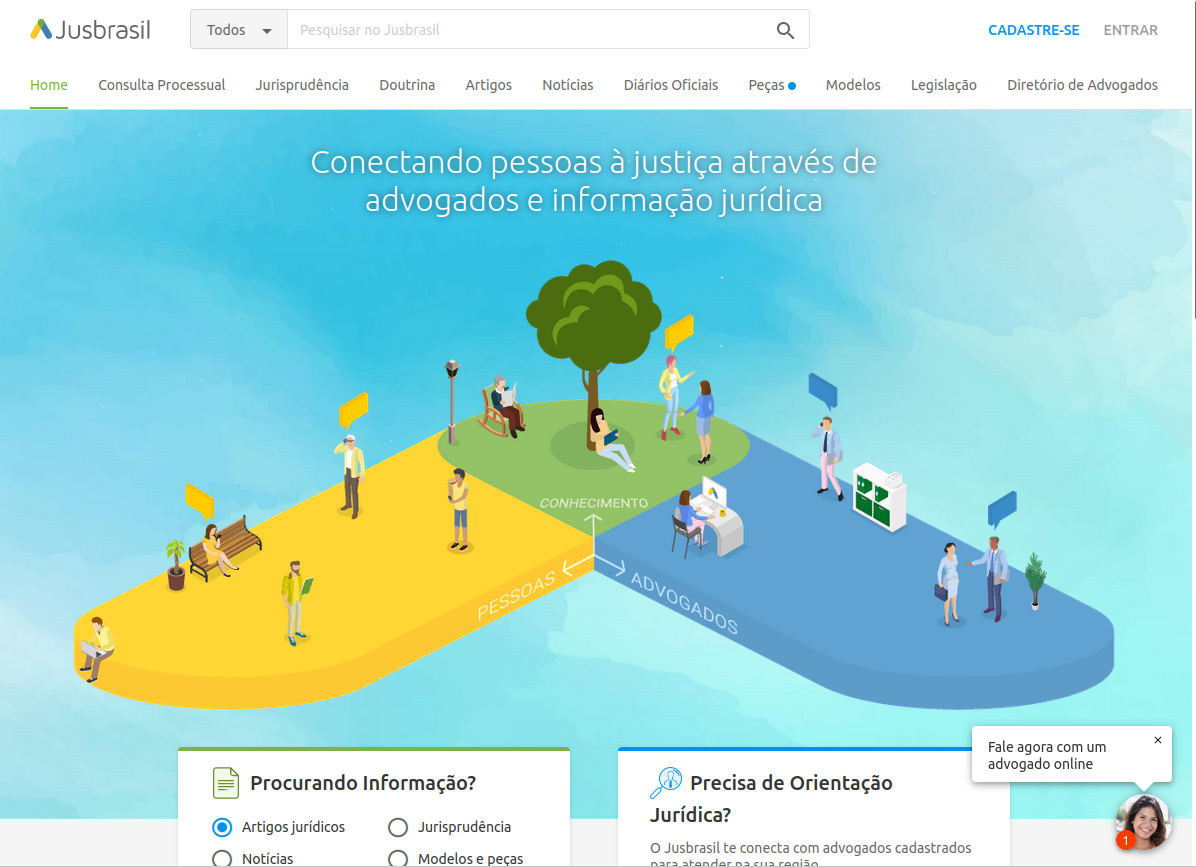

Fonte: jusbrasil.com.br


Essa afirmação foi feita há 5 anos.

O número de usuários do JusBrasil evidencia duas coisas: o tamanho do mercado jurídico brasileiro e a centralidade da busca textual para as mais diferentes carreiras jurídicas.

O texto abaixo é parte de uma decisão do Supremo Tribunal Federal sobre pedido de habeas corpus:

In [ ]:
decisao = """DECISÃO: Trata-se de “habeas corpus”, com pedido de medida liminar, 
impetrado contra decisão emanada de eminente Ministro de Tribunal 
Superior da União que, em sede de outra ação de “habeas corpus” ainda em 
curso no Superior Tribunal de Justiça (HC 390.905/SP), indeferiu medida 
liminar que lhe havia sido requerida em favor do ora paciente.

Sendo esse o contexto, passo a apreciar a admissibilidade, na espécie, 
da presente ação de “habeas corpus”. E, ao fazê-lo, devo observar que ambas 
as Turmas do Supremo Tribunal Federal firmaram orientação no sentido da 
incognoscibilidade desse remédio constitucional, quando impetrado, como 
no caso ora em análise, contra decisão monocrática proferida por Ministro 
de Tribunal Superior da União (HC 116.875/AC, Rel. Min. CÁRMEN 
LÚCIA – HC 117.346/SP, Rel. Min. CÁRMEN LÚCIA – HC 117.798/SP, 
Rel. Min. RICARDO LEWANDOWSKI – HC 118.189/MG, Rel. 
Min. RICARDO LEWANDOWSKI – HC 119.821/TO, Rel. Min. GILMAR 
MENDES – HC 121.684-AgR/SP, Rel. Min. TEORI ZAVASCKI – 
HC 122.381-AgR/SP, Rel. Min. DIAS TOFFOLI – HC 122.718/SP, Rel. 
Min. ROSA WEBER – RHC 114.737/RN, Rel. Min. CÁRMEN LÚCIA – 
RHC 114.961/SP, Rel. Min. DIAS TOFFOLI, v.g.)"""

É possível identificar rapidamente, a olho nu, todas as menções a precedentes nesse texto. A maioria das decisões judiciais é muito mais longa do que isso. Muitas decisões do próprio STF possuem mais de 100 páginas de extensão. Para procurar precedentes citados na decisão e, assim, compreender os argumentos jurídicos adotados pelo tribunal, existe a opção de ler toda a decisão página a página. Mas essa é uma alternativa obviamente demorada e pouco eficiente. Na 60a página o olhar humano, já cansado, pode deixar passar um precedente citado. 

Outra alternativa é realizar a busca usando ferramentas computacionais. 

In [ ]:
decisao.find('HC')

249

In [ ]:
decisao.count('HC')

11

Com os métodos básicos de análise de strings que já aprendemos os resultados são limitados. Como vimos em aula anterior, letras maíusculas e minúsculas já criam um problema. 

O maior deles, no entanto, é que 'find()' e 'count()' buscam strings exatas. Isso significa que, ao buscar as citações a precedentes judicias nessa decisão do STF, nunca vamos poder fazer uma busca mais abrangente, que retorne de uma vez todos os HCs citados. 

As expressões regulares resolvem esse problema. Enquanto 'find()' e 'count()' seguem uma lógica de match idêntico, expressões regulares seguem uma lógica de regras gerais que permitem flexibilidade. No lugar de determinar uma string específica para um match idêntico, expressões regulares permitem estabelecer padrões.

Considere a string 'HC'. Uma maneira de estabelecer um padrão que identifique essa string é:

**Letra\Letra**

Essa regra abarca o caso da string 'HC', porém também abarca várias outras partes da string da decisão. Uma regra mais específica seria:

**H\C**

Vamos testar essa regra usando a biblioteca de expressões regulares.


In [ ]:
import re
regra_simples = re.compile(r'HC')

Primeiro, importamos a biblioteca de expressões regulares. Depois, usamos a função 'compile()', pertencente a essa biblioteca, para estabelecer nossa regra geral e salvá-la na variável 'regra_simples'. A função 'compile()' recebe como argumento uma regra geral expressada em formato de string 'crua', com o 'r' de 'raw', na frente.

Em seguida, utilizados o método 'findall()' para procurar em 'decisao' todas as ocorrências de strings que cumprem a regra geral estabelecida (**H\C**).
O método 'findall()' é aplicado sobre uma regra geral previamente definida - nesse caso, 'regra_simples' - e recebe como argumento a string dentro da qual queremos procurar as incidências dessa regra geral.

In [ ]:
regra_simples.findall(decisao)

['HC', 'HC', 'HC', 'HC', 'HC', 'HC', 'HC', 'HC', 'HC', 'HC', 'HC']

Encontramos todas as ocorrências de citações a precedente de habeas corpus na decisão do STF.

Mas esse resultado não nos permite saber quais habeas corpus estão sendo citados.

Vamos escolher alguns deles, citados na decisão, para construir uma regra geral melhor.

In [ ]:
precedente1 = 'HC 390.905/SP'
precedente2 = 'HC 116.875/AC'
precedente3 = 'HC 117.346/SP'

Considere as strings dos três precedentes acima. Que tipos de padrões podemos identificar?

-O primeiro caractere é sempre H

-O segundo caractere é sempre C

-O terceiro caractere é sempre um espaço

-O quarto caractere é sempre um dígito

-O quinto caractere é sempre um dígito

-O sexto caractere é sempre um dígito

-O sétimo caractere é sempre um ponto

-O oitavo caractere é sempre um dígito

-O nono caractere é sempre um dígito

-O décimo caractere é sempre um dígito

-O décimo primeiro caractere é sempre uma barra

-O décimo segundo caractere é sempre uma letra

-O décimo terceiro caractere é sempre uma letra

Uma maneira de expressar o padrão é colocar as possibilidades lado a lado, como apareceriam em cada ocorrência da citação a precedente:

**HC\Espaço\Dígito\Dígito\Dígito\Ponto\Dígito\Dígito\Dígito\Barra\Letra\Letra**

Isso nos leva a uma maneira simplificada de expressar o padrão. Podemos simplificar ainda mais usando apenas abreviaturas:

**HC\E\D\D\D\P\D\D\D\B\L\L**

Na verdade, o que fizemos foi analisar três casos concretos e construir uma regra geral que abranja todos eles. Uma regra geral precisa ser bem calibrada para abarcar todos os casos que queremos e apenas os casos que queremos. Técnica legislativa é exatamente isso: formular o dispositivo legal que permite a incidência em todos os casos corretos.

Nossa regra geral aqui poderia ser:

**HC\Espaço\Dígito\Dígito\Dígito\Ponto\Dígito\Dígito\Dígito\BarraSP**

Essa regra é mais específica. Ela incidiria sobre as strings precedente1 e precedente3. Mas acabaria falhando em abarcar precedente2. 

As expressões regulares permitem expressar no Python justamente essas regras gerais para abarcar um conjunto de ocorrências de strings. Mas os nomes de categorias e objetos estão todos em inglês, então vamos traduzir nossa regra geral:

**HC\Space\Digit\Digit\Digit\Not Word\Digit\Digit\Digit\Not Word\Word\Word**

Assim indicamos onde na string devem aparecer espaços (space), onde devem aparecer números ou dígitos (digit), onde devem aparecer letras como partes de uma palavra (word) e onde devem aparecer caracteres que não são parte de uma palavra (not word).

Em Python, portanto, nossa regra geral ou expressão regular será:

**HC\s\d\d\d\W\d\d\d\W\w\w**

Note que se uma letra ou parte de palavra é 'w', de 'word', então podemos expressar seu oposto - qualquer caractere que não seja letra - com 'W'. 
O mesmo vale para as outras siglas. 

In [ ]:
import re

regra_hc = re.compile(r'HC\s\d\d\d\W\d\d\d\W\w\w')

In [ ]:
print('\\W' in str(regra_hc))

True


Primeiro, importamos a biblioteca de expressões regulares.

Depois, salvamos em 'regra_hc' nossa regra geral para identificar todas as citações de precedente de habeas corpus na decisão do STF. Usamos exatamente o formato que foi construído passo-a-passo.

In [ ]:
regra_hc.findall(decisao)

['HC 390.905/SP',
 'HC 116.875/AC',
 'HC 117.346/SP',
 'HC 117.798/SP',
 'HC 118.189/MG',
 'HC 119.821/TO',
 'HC 121.684-Ag',
 'HC 122.381-Ag',
 'HC 122.718/SP',
 'HC 114.737/RN',
 'HC 114.961/SP']

Podemos testar a regra mais específica que foi considerada antes, na qual os últimos dois caracteres são sempre 'SP':

In [ ]:
regra_sp = re.compile(r'HC\s\d\d\d\W\d\d\d\WSP')
regra_sp.findall(decisao)

['HC 390.905/SP',
 'HC 117.346/SP',
 'HC 117.798/SP',
 'HC 122.718/SP',
 'HC 114.961/SP']

Essa regra ou expressão regular permite identificar alguns dos precedentes que aparecem no texto da decisão, porém não todos.

É uma regra que incide sobre menos casos do que gostaríamos. É sub-inclusiva.

Outro exemplo útil é a necessidade de identificar, no texto de uma decisão, citações a precedentes do controle abstrato de constitucionalidade.

In [ ]:
decisao_controle = """A legitimidade ativa do requerente é patente, visto tratar-se de partido político com
 representação no Congresso Nacional e, portanto, legitimado universal apto à 
 jurisdição do controle abstrato de constitucionalidade. Em relação à irregularidade
 na representação processual, a AGU alega que a procuração não tem poderes especiais
 para a impugnação da Portaria GP nº 69/2019. No entanto, a procuração outorga poderes
 para “ingressar com Arguição de Descumprimento de Preceito Fundamental, em face da abertura
 de inquérito genérico por supostos ataques à imagem pública do STF e de seus membros. ”
 É o suficiente para atender à exigência de “descrição mínima do objeto digno de hostilização”
 (ADPF 480 AgR, Relator (a): Min. EDSON FACHIN, Tribunal (...) Conforme entendimento 
 iterativo desta Corte, “meio eficaz de sanar a lesão é aquele apto a solver a controvérsia
 constitucional relevante de forma ampla, geral e imediata. No juízo de subsidiariedade há
 de se ter em vista, especialmente, os demais processos objetivos já consolidados no sistema
constitucional” (ADPF 388, Rel. Min. Gilmar Mendes, Tribunal Pleno, DJe 01.08.2016)"""

Dois precedentes diferentes são citados no texto dessa decisão do STF:

In [ ]:
precedente4 = 'ADPF 480 AgR'
precedente5 = 'ADPF 388'

Qual a regra geral que abarcaria essas duas strings dentro do texto, sem ser abrangente demais?

**\Letra\Letra\Letra\Letra\Espaço\Dígito\Digito\Dígito**

Ou, passando para inglês, as abreviaturas seriam:

**\w\w\w\w\s\d\d\d**

Vamos testar essa regra geral:

In [ ]:
regra_controle = re.compile(r'\w\w\w\w\s\d\d\d')
regra_controle.findall(decisao_controle)

['ADPF 480', 'ADPF 388']

Talvez nossa regra esteja genérica demais. Sabemos que em ambos os casos a citação ao precedente começa com 'ADPF'. Então podemos ter:

**ADPF\Espaço\Dígito\Dígito\Dígito**

Ou:

**ADPF\s\d\d\d**

In [ ]:
regra_controle = re.compile(r'ADPF\s\d\d\d')
regra_controle.findall(decisao_controle)

2

Até aqui temos os seguintes elementos para construir regras gerais usando expressões regulares:

\d - Dígito (0-9)

\D - Qualquer coisa que não seja um dígito (0-9)

\w - "Word Character" (a-z, A-Z, 0-9, _)

\W - Qualquer coisa que não seja um "Word Character"

\s - Espaços em branco (espaço, tab, nova linha)

\S - Qualquer coisa que não seja um espaço em branco

Note que nossas regras gerais para encontrar citações a precedente continham vários dígitos seguidos. É possível simplificar isso, indicando o total de dígitos em sequência.

No lugar de

**HC\Espaço\Dígito\Dígito\Dígito\Ponto\Dígito\Dígito\Dígito\Barra\Letra\Letra**

Podemos expressar a mesma regra da seguinte forma:

**HC\Espaço\Dígito{3}Ponto\Dígito{3}\Barra\Letra{2}**

No lugar de

**ADPF\Espaço\Dígito\Dígito\Dígito**

Podemos expressar a mesma regra da seguinte forma:

**ADPF\Espaço\Dígito{3}**



In [ ]:
regra_hc = re.compile(r'HC\s\d{3}\W\d{3}\W\w{2}')
regra_hc.findall(decisao)

['HC 390.905/SP',
 'HC 116.875/AC',
 'HC 117.346/SP',
 'HC 117.798/SP',
 'HC 118.189/MG',
 'HC 119.821/TO',
 'HC 121.684-Ag',
 'HC 122.381-Ag',
 'HC 122.718/SP',
 'HC 114.737/RN',
 'HC 114.961/SP']

In [ ]:
regra_controle = re.compile(r'ADPF\s\d{3}')
regra_controle.findall(decisao_controle)

['ADPF 480', 'ADPF 388']

Então podemos determinar sequências de caracteres do mesmo tipo usando esse formato:

{3} - Número exato

{3, 4} - Range de números (mínimo, máximo)

**Mais regras**

.      Qualquer caractere exceto nova linha

\d     Dígito (0-9)

\D     Qualquer coisa que não seja um dígito (0-9)

\w     "Word Character" (a-z, A-Z, 0-9, _)

\W     Qualquer coisa que não seja um "Word Character"

\s     Espaços em branco (espaço, tab, nova linha)

\S     Qualquer coisa que não seja um espaço em branco


\b     Limite de palavra

\B     Meio de palavra

^      Começo de string

$      Final de string


[ ]    Dá match nos caracteres dentro dos colchetes

[^ ]   Dá match quando não encontrar os caracteres dos colchetes


Quantificadores:

\*     0 ou mais

\+     1 ou mais

{3}    Número exato

{3, 4}   Range de números (mínimo, máximo)

## Edição de Documentos <a class="anchor" id="second-bullet"></a>


Usando a interface gráfica do Windows, MacOS, Android ou outro sistema operacional, a criação de novos documentos de texto é uma tarefa corriqueira. Assim como é possível criar, editar e salvar documentos de texto usando a interface gráfica, também é possível criar, editar e salvar documentos de texto usando Python.

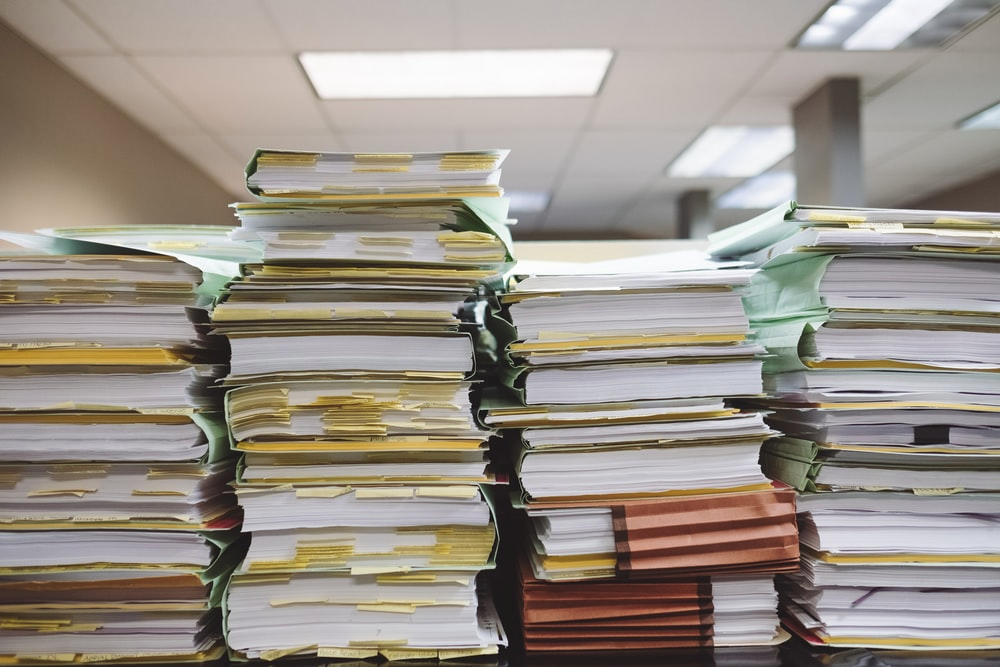

*Fonte: unsplash.com*

Podemos criar, editar e salvar os mais variados tipos de arquivos usando Python - mas para juristas o tipo de arquivo mais frequentemente usado é obviamente o arquivo de texto. Em aulas anteriores já vimos exemplos de arquivos salvos em alguma pasta sendo abertos via Python. Na aula 6, quando lidamos com strings contendo partes da Constituição, importamos o texto completo dela que estava salvo em um arquivo.

Primeiro, importamos o módulo drive da biblioteca google.colab. Usando a função 'mount()' desse módulo, acessamos nossas pastas na nuvem do Google Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Feito isso, podemos abrir, editar e salvar arquivos de nosso Google Drive. O arquivo usado na aula 6 se chama 'Constituicao' e a extensão dele é '.txt'. 

In [ ]:
arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Constituicao.txt',encoding='iso-8859-1')

A função 'open()' é nativa do Python. Não é necessário importar nenhuma biblioteca para usá-la. 

Open() recebe no mínimo 1 argumento: o arquivo que será aberto. Esse argumento possui formato de string. O texto dessa string é o local - pasta, subpasta - onde o arquivo está salvo.

**Dica**

Se você está programando em um arquivo .py que é rodado no seu próprio computador (e não na nuvem, como é o caso desse Notebook) então é possível que o arquivo a ser aberto já esteja salvo na mesma pasta do seu arquivo .py. Nesse caso, a string passada como argumento de open() pode conter apenas o nome e extensão do arquivo, sem toda a especificação das pastas e subpastas. 




**Encoding**

Embora open() não exija mais de um argumento, existem argumentos facultativos. Nessa chamada de open() estamos passando um segundo argumento que se chama 'encoding'. Isso permite informar se o texto do arquivo deve ser lido levando em conta apenas os caracteres da língua inglesa ou os caracteres existentes em outras línguas. Se 'encoding' não for passado como argumento, o texto do arquivo será lido com encoding UTF-8, língua inglesa e isso pode resultar em erro. 

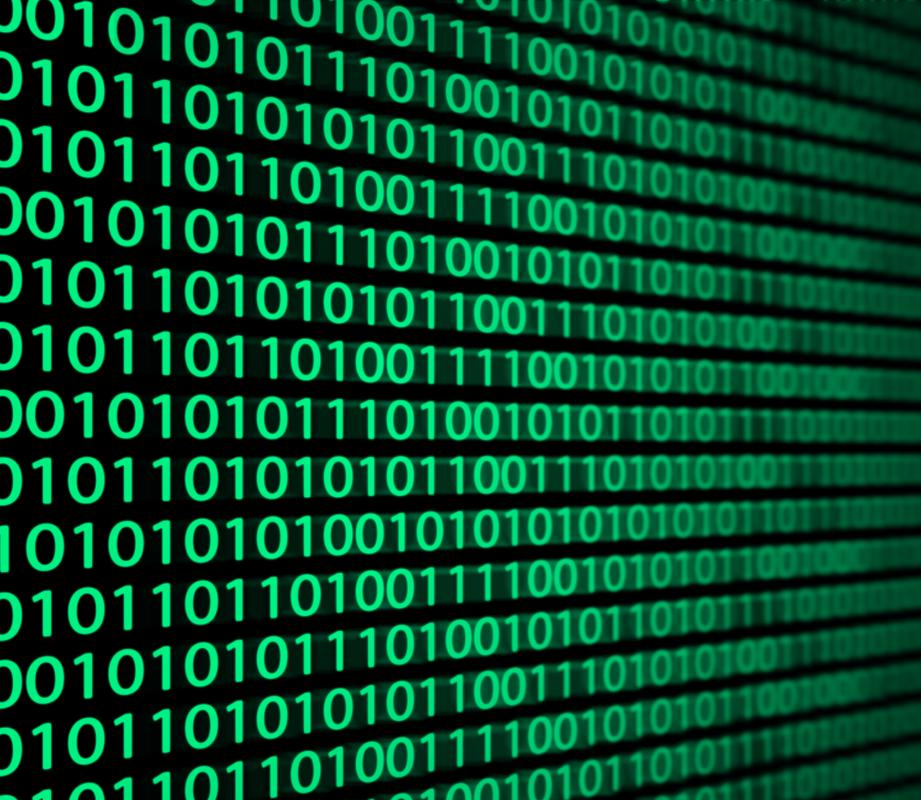

*Fonte: easytechjunkie.com*

Esse erro ocorre quando a máquina tenta 'traduzir' ou 'encodificar' o texto da língua dela - 0s e 1s - para a língua que visualizamos na tela - texto.

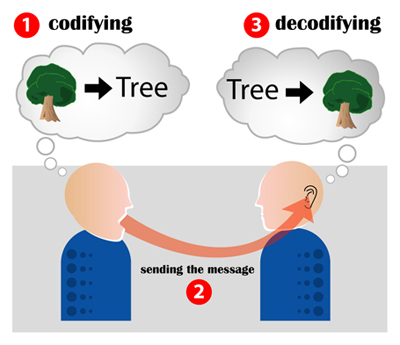

*Fonte: Wikimedia.org*

Sabemos que nosso texto da Constituição está em português e possui caracteres não existentes da língua inglesa, como 'ê'. Por essa razão passamos o segundo argumento facultativo instruindo a máquina para ler o texto considerando caracteres de línguas latinas.

**Dica**

Você pode adotar como prática, sempre que abrir um arquivo contendo texto em português, fornecer o segundo argumento exatamente nesse formato:

encoding='iso-8859-1'

**O que a chamada de 'open()' retorna**

Ao executar 'open()' acima, salvamos o retorno dessa chamada na variável 'arquivo'.

In [ ]:
type(arquivo)

_io.TextIOWrapper

O objeto salvo em 'arquivo' é do tipo file. Não é um objeto do tipo string. A classe file possui seus próprios métodos - assim como existem métodos específicos para strings, métodos específicos para listas e assim por diante.

Um dos métodos da classe file é 'read()':

In [ ]:
cf_completa = arquivo.read()
print(cf_completa[:2000])
arquivo.close()






CÂMARA DOS DEPUTADOS
Centro de Documentação e Informação


CONSTITUIÇÃO DA REPÚBLICA FEDERATIVA DO BRASIL

PREÂMBULO


         Nós, representantes do povo brasileiro, reunidos em Assembléia Nacional Constituinte para instituir um Estado democrático, destinado a assegurar o exercício dos direitos sociais e individuais, a liberdade, a segurança, o bem-estar, o desenvolvimento, a igualdade e a justiça como valores supremos de uma sociedade fraterna, pluralista e sem preconceitos, fundada na harmonia social e comprometida, na ordem interna e internacional, com a solução pacífica das controvérsias, promulgamos, sob a proteção de Deus, a seguinte Constituição da República Federativa do Brasil. 
         
TÍTULO I 
DOS PRINCÍPIOS FUNDAMENTAIS
         
         Art. 1º A República Federativa do Brasil, formada pela união indissolúvel dos Estados e Municípios e do Distrito Federal, constitui-se em Estado democrático de direito e tem como fundamentos: 
         I - a soberania; 
         

Aplicado a um objeto do tipo file, o método 'read()' retorna o conteúdo do arquivo. Nesse caso, a string do conteúdo do arquivo é retornada e salva na variável 'cf_completa'. Você deve lembrar que usamos essa estratégia para ter o texto completo da Constituição salvo em 'cf_completa' anteriormente.

Também podemos usar o método 'readlines()'.

In [ ]:
arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Constituicao.txt',encoding='iso-8859-1')
cf_linhas = arquivo.readlines()

cf_linhas[:10]

['\n',
 '\n',
 '\n',
 '\n',
 '\n',
 'CÂMARA DOS DEPUTADOS\n',
 'Centro de Documentação e Informação\n',
 '\n',
 '\n',
 'CONSTITUIÇÃO DA REPÚBLICA FEDERATIVA DO BRASIL\n']

O método 'readlines()' devolve uma lista contendo strings. Cada string é o conteúdo de uma linha separada do arquivo.

Atenção: após executar o método 'read()' ou 'readlines()' em um objeto file, ele é esgotado. Não contém mais nada. Isso porque 'read()' e 'readlines()' extraem o conteúdo do objeto file.

Por isso no bloco acima, após já termos usado 'read()', fomos obrigados a chamar mais uma vez 'open()' para obter um arquivo file intocado.

In [ ]:
cf_completa = arquivo.read()
cf_completa[:2000]

''

Assim como no Windows, MacOS, Android etc todo arquivo que foi aberto precisa ser em algum momento fechado. Isso também ocorre no Python. O método 'close()' fecha um arquivo.
A chamada de 'close()' não retorna nada, apenas muda o status do objeto file sobre o qual é executada.

In [ ]:
arquivo.close()

Veja o que acontece se abrimos o arquivo, fechamos e depois de fechar tentamos ler suas linhas:

In [ ]:
arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Constituicao.txt',encoding='iso-8859-1')
arquivo.close()
arquivo.readlines()[:10]

ValueError: ignored

A mensagem de erro informa que não podemos tentar ler um arquivo que está fechado.

Mas por qual razão fecharíamos o arquivo via Python após tê-lo aberto? Por que não simplesmente deixá-lo aberto?

Lembre-se que no Word você pode abrir um arquivo com um trabalho que está escrevendo e editá-lo enquanto está aberto. Mas em algum momento irá parar de editar o arquivo e se deixá-lo aberto corre o risco de alterar seu conteúdo sem querer (por exemplo, apagando metade das páginas do trabalho). 

Qual a solução? Fechar o arquivo quando não pretende mais editá-lo.

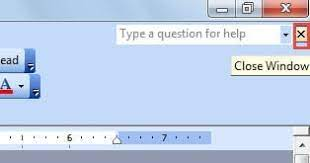

*Fonte: datanumen.com*

Como hábito, procure sempre fechar os arquivos no Python quando não irá mais usá-los. 

Isso é especialmente importante quando o arquivo foi aberto pelo Python no formato de edição.

A função 'open()' possui um argumento obrigatório que já vimos: o local e nome do arquivo no seu computador.

Possui um argumento facultativo para comandar o encoding.

Mas possui também um argumento facultativo para determinar se o arquivo será aberto em modo somente leitura (read)

'r'

Ao tentar abrir um arquivo em modo leitura, se ele não existe ainda, haverá erro.

O arquivo também pode ser aberto em modo de edição (write)

'w'  

Ao tentar abrir um arquivo em modo edição, se ele não existe ainda, o arquivo será automaticamente criado. Se o arquivo já existe e texto for inserido nele com a abertura no formato 'w', o texto pré-existente no arquivo será apagado.

O arquivo pode ainda ser aberto em modo de inserção ou append.

'a'

 Isso é: ao abrir o arquivo, qualquer texto pré-existente será mantido e novos textos serão inseridos ao final do arquivo. 



Esse argumento é o formato da abertura do arquivo. Deve ser o segundo argumento passado ou então, se for passado em terceiro, quarto etc deve ser explicitado:

mode='w'

ou

mode='a'

Quando esse argumento não é passado, seu valor padrão adotado é 'r'.




In [ ]:
arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Exemplos/exemplo1.txt', 'w', encoding='iso-8859-1')

Criamos o arquivo acima, na pasta 'Exemplos'. Agora que ele está aberto em modo de leitura e edição, podemos adicionar texto a ele.

In [ ]:
arquivo.write("EXCELENTÍSSIMA SENHORA DOUTORA JUIZA DE DIREITO DA __ VARA CÍVEL DA COMARCA DA CAPITAL")

86

In [ ]:
arquivo.close()

Podemos agora abrir esse arquivo na pasta 'Exemplos' usando a interface gráfica do computador para confirmar se nossa string foi inserida.

Também podemos abrir esse arquivo pelo Python para ler seu conteúdo.

In [ ]:
arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Exemplos/exemplo1.txt', mode='r', encoding='iso-8859-1')
conteudo = arquivo.readlines()
print(conteudo)
arquivo.close()

['EXCELENTÍSSIMA SENHORA DOUTORA JUIZA DE DIREITO DA __ VARA CÍVEL DA COMARCA DA CAPITAL']


O método 'write()' insere um objeto string no arquivo. O método 'writelines()' permite inserir um objeto lista no arquivo. Os objetos da lista serão escritos no arquivo.

In [ ]:
arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Exemplos/exemplo1.txt', 'a', encoding='iso-8859-1')
arquivo.writelines(['\n\nQualificação da parte autora aqui \n\n', 'Apresenta Ação de Obrigação de Fazer Cumulada com Pedido de Condenação em Danos Morais\n\n', 'Qualificação da parte ré aqui\n\n','Fundamentos: ...'])
arquivo.close()

Essa última chamada da função 'open()' foi feita com o argumento 'a'. Assim o cabeçalho da petição que já havia sido inserido no arquivo antes é mantido e a lista com strings é escrita no arquivo após o final do texto pré-existente.

Note que após as aberturas para editar o arquivo - seja com 'w' para write, seja com 'a' para append - sempre executamos o método 'close()' para fechar o arquivo.

Agora usamos o 'open()' com 'r' de read, apenas para ler seu conteúdo atual.

In [ ]:
arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Exemplos/exemplo1.txt', mode='r', encoding='iso-8859-1')
conteudo = arquivo.readlines()
print(conteudo)
arquivo.close()

['EXCELENTÍSSIMA SENHORA DOUTORA JUIZA DE DIREITO DA __ VARA CÍVEL DA COMARCA DA CAPITAL\n', '\n', 'Qualificação da parte autora aqui \n', '\n', 'Apresenta Ação de Obrigação de Fazer Cumulada com Pedido de Condenação em Danos Morais\n', '\n', 'Qualificação da parte ré aqui\n', '\n', 'Fundamentos: ...']


Com essas ferramentas você já pode criar, editar e salvar grandes massas de documentos jurídicos usando poucas linhas de código. Isso é uma demanda frequente em escritórios de advocacia. Estagiários muitas vezes são responsáveis por fazer pequenas alterações a documentos 'modelo'. Modelos de peças jurídicas estão disponíveis livremente.

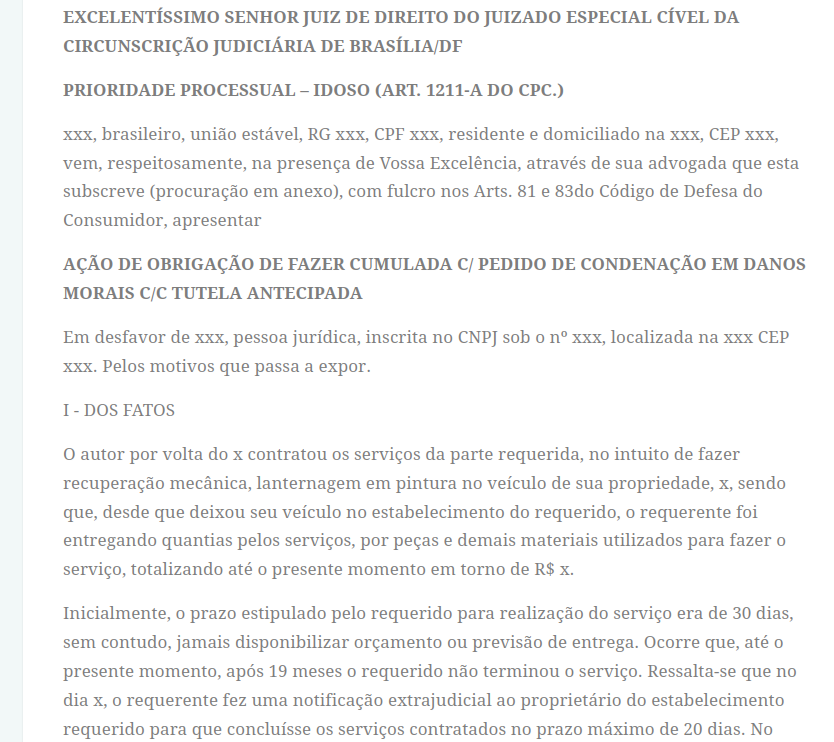

*Fonte: juridicocerto.com*

In [ ]:
clientes = [('José Silva', 9090230, 'Rua Quatá 200'),
            ('Maria Rocha', 4839121, 'Avenida Faria Lima 451'),
            ('Leandro Leal', 58192181, 'Rua Quatá 300')]


for cliente in clientes:
  nome = cliente[0]
  rg = cliente[1]
  endereco = cliente[2]
  modelo = f"""EXCELENTÍSSIMA SENHORA JUIZA DE DIREITO DO __ JUIZADO ESPECIAL CÍVEL DE SÃO PAULO

{nome}, brasileiro, união estável, RG {rg}, CPF xxx, residente e domiciliado em {endereco}, 
vem, respeitosamente, na presença de Vossa Excelência, através de sua advogada que esta subscreve 
(procuração em anexo), com fulcro nos Arts. 81 e 83 do Código de Defesa do Consumidor, apresentar

AÇÃO DE OBRIGAÇÃO DE FAZER CUMULADA C/ PEDIDO DE CONDENAÇÃO EM DANOS MORAIS C/C TUTELA ANTECIPADA

Em desfavor de xxx, pessoa jurídica, inscrita no CNPJ sob o nº xxx, localizada na xxx CEP xxx. 
Pelos motivos que passa a expor.

I - DOS FATOS

O autor por volta do x contratou..."""
  arquivo = open('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/Exemplos/'+nome+'.txt', 'w', encoding='iso-8859-1')
  arquivo.write(modelo)
  arquivo.close()

O código acima usa tuplas de uma lista. Cada tupla possui informações básicas sobre a parte autora. 
O 'for loop' itera sobre a lista e, para cada cliente, cria, edita e salva um arquivo de texto usando um template de petição inicial.

EOF